# Logistic Regression

Imports and helpers

In [1]:
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import numpy as np

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Model Training

model setup and random search 

In [6]:
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_params = {
    'C': uniform(0.01, 20.0),
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'class_weight': [None, 'balanced']
}

Initialize RandomizedSearchCV (3-fold cross-validation acts as our validation set)

In [7]:
lr_search = RandomizedSearchCV(lr_model, lr_params, 
                               n_iter=50, cv=5, scoring='accuracy', 
                               random_state=42, n_jobs=-1, verbose=1)

Extract best models

In [8]:
print("Training Logistic Regression...")
start_time = time.time()
lr_search.fit(X_train, y_train)
lr_train_time = time.time() - start_time
print(f"Logistic Regression training completed Completed in {lr_train_time:.2f}s.")
print("Let's choose the best estimator...")
best_lr = lr_search.best_estimator_
print(f"Best Logistic Regression params: {lr_search.best_params_}")

Training Logistic Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Logistic Regression training completed Completed in 588.67s.
Let's choose the best estimator...
Best Logistic Regression params: {'C': np.float64(4.256782213565523), 'class_weight': 'balanced', 'solver': 'liblinear'}


## Model Evaluation

Predict on the X_valid

In [9]:
y_valid_pred = best_lr.predict(X_valid)
print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")

Validation Accuracy: 0.8920


Classification Report

In [19]:
print("Classification Report for model evaluation:")
print(classification_report(y_valid, y_valid_pred, target_names=['Negative', 'Positive']))
print(f"Training Time: {lr_train_time:.4f} seconds")

Classification Report for model evaluation:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89     10003
    Positive       0.89      0.89      0.89      9997

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000

Training Time: 588.6705 seconds


confusion matrices

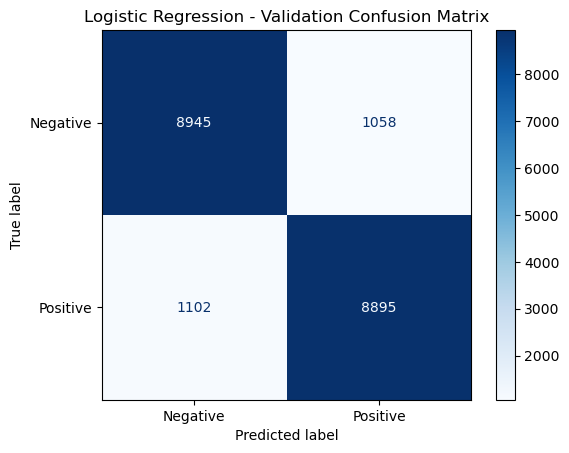

Confusion Matrix:
[[8945 1058]
 [1102 8895]]

True Negatives: 8945
False Positives: 1058
False Negatives: 1102
True Positives: 8895


In [ ]:
cm_valid = confusion_matrix(y_valid, y_valid_pred)
ConfusionMatrixDisplay(cm_valid, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Logistic Regression - Validation Confusion Matrix')
plt.savefig('docs/02_results/logistic_regression_validation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm_valid}")
print(f"\nTrue Negatives: {cm_valid[0,0]}")
print(f"False Positives: {cm_valid[0,1]}")
print(f"False Negatives: {cm_valid[1,0]}")
print(f"True Positives: {cm_valid[1,1]}")

based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on validation dataset

## Model Testing


Predict on the X_test 

In [12]:
y_test_pred = best_lr.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

Test Accuracy: 0.8898


Classification Report

In [18]:
print("Classification Report for model testing:")
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))
print(f"Training Time: {lr_train_time:.4f} seconds")

Classification Report for model testing:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      9966
    Positive       0.89      0.89      0.89     10034

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000

Training Time: 588.6705 seconds


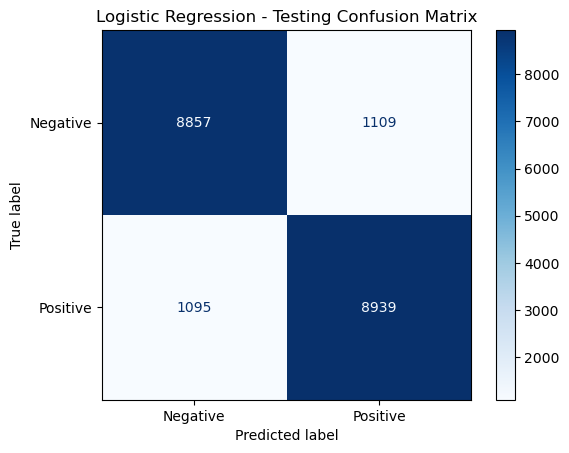

Confusion Matrix:
[[8857 1109]
 [1095 8939]]

True Negatives: 8857
False Positives: 1109
False Negatives: 1095
True Positives: 8939


In [ ]:
cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Logistic Regression - Testing Confusion Matrix')
plt.savefig('docs/02_results/logistic_regression_testing_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm_test}")
print(f"\nTrue Negatives: {cm_test[0,0]}")
print(f"False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}")
print(f"True Positives: {cm_test[1,1]}")

based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on testing dataset

## visualizations (validation and testing Confusion Matrix)

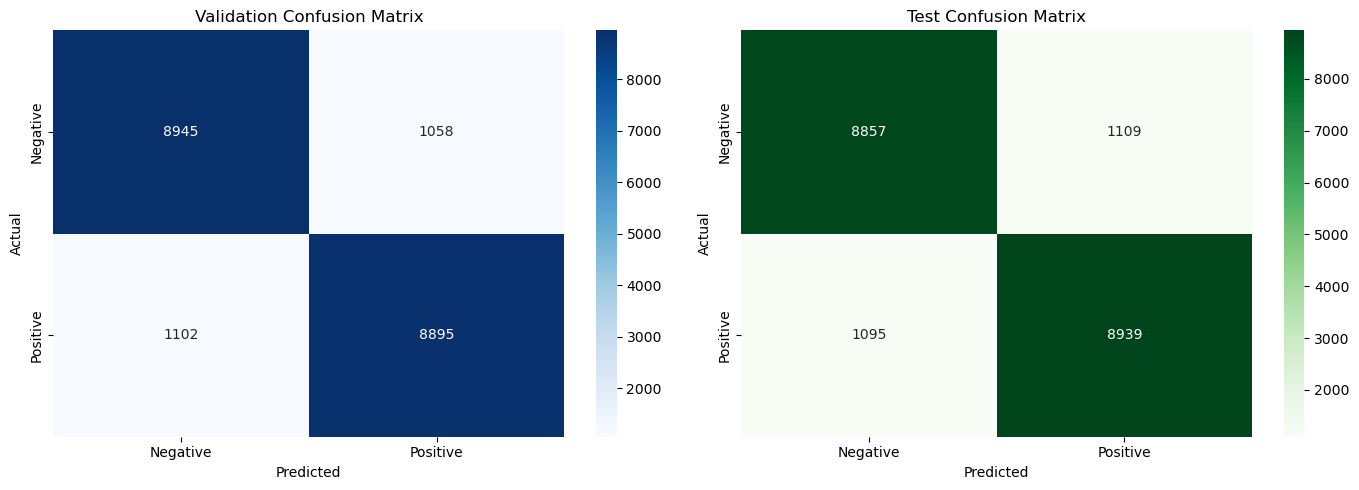

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = best_lr.classes_
ticklabels = ['Negative', 'Positive']

sns.heatmap(confusion_matrix(y_valid, y_valid_pred, labels=classes), 
            annot=True, fmt='d', cmap='Blues', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[0])
axes[0].set_title('Validation Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_test_pred, labels=classes), 
            annot=True, fmt='d', cmap='Greens', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('docs/02_results/logistic_regression_valid_test_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

##  Feature Inspection

In [16]:
import pandas as pd
import joblib
from pathlib import Path

vec_path = Path('data/vectorizers/tfidf_vectorizer.joblib')

vectorizer_obj = globals().get('vectorizer', None)
if vectorizer_obj is None and vec_path.exists():
    try:
        vectorizer_obj = joblib.load(vec_path)
    except Exception:
        vectorizer_obj = None

if vectorizer_obj is not None and hasattr(best_lr, 'coef_'):
    feature_names = (vectorizer_obj.get_feature_names_out()
                     if hasattr(vectorizer_obj, 'get_feature_names_out')
                     else vectorizer_obj.get_feature_names())

    coefs = best_lr.coef_.ravel()
    top_pos_idx = coefs.argsort()[::-1][:20]
    top_neg_idx = coefs.argsort()[:20]

    pos_features = [feature_names[i] for i in top_pos_idx]
    pos_coefs = [round(coefs[i], 4) for i in top_pos_idx]
    neg_features = [feature_names[i] for i in top_neg_idx]
    neg_coefs = [round(coefs[i], 4) for i in top_neg_idx]

    feature_importance_df = pd.DataFrame({
        'Top Positive Features': pos_features,
        'Pos Weight': pos_coefs,
        'Top Negative Features': neg_features,
        'Neg Weight': neg_coefs
    })
    feature_importance_df.index = feature_importance_df.index + 1

    print("\n--- Model Feature Importance (Top 20) ---")
    try:
        display(feature_importance_df)
    except NameError:
        print(feature_importance_df.to_string())

else:
    print('Vectorizer not found or model has no coef_. Save vectorizer to data/vectorizers/tfidf_vectorizer.joblib to enable feature inspection.')


--- Model Feature Importance (Top 20) ---


,Top Positive Features,Pos Weight,Top Negative Features,Neg Weight
1,great,15.5568,not,-14.9613
2,excellent,12.0969,worst,-13.7975
3,not disappointed,11.8770,not worth,-13.4008
4,love,10.4686,disappointed,-12.7579
5,perfect,9.9276,boring,-12.5251
6,wonderful,9.2333,not recommend,-11.8239
7,easy,8.8802,disappointing,-11.0802
8,best,8.8132,not buy,-10.6682
9,awesome,8.2715,poor,-10.5567
10,no problem,8.1968,terrible,-10.1942


## Saving the Model

In [17]:
save(model_base='data/models', model=best_lr, model_name='05_logistic_regression_classifier.joblib')

Saved model 05_logistic_regression_classifier.joblib to data/models/05_logistic_regression_classifier.joblib


{'model': PosixPath('data/models/05_logistic_regression_classifier.joblib')}

## Summary